In [2]:
import pandas as pd

In [3]:
dataset_code = pd.read_csv("/data4/telecom_NER/code_agent/Leetcode Data.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/data4/telecom_NER/code_agent/Leetcode Data.csv'

In [3]:
dataset_code.columns

Index(['ID', 'Title', 'Difficulty', 'Link', 'Topics', 'Acceptance Rate (%)',
       'Premium Only', 'Category', 'Likes', 'Dislikes', 'Example Test Cases',
       'Similar Questions'],
      dtype='object')

In [4]:
"""
Adaptive LeetCode Problem Solving System
=========================================
Knowledge Graph + Sentence Transformer embeddings + Skill-based question selection
with 60-iteration simulation.
"""

import pandas as pd
import numpy as np
import random
import time
import math
import json
import ast
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Optional

# ── Sentence Transformers ──────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# ── Graph ──────────────────────────────────────────────────────────────────────
import networkx as nx

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  1.  DATA LOADING & CLEANING                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def load_dataset(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # ── normalise column names ──
    df.columns = [c.strip() for c in df.columns]

    # ── numeric coercions ──
    df["Acceptance Rate (%)"] = pd.to_numeric(df["Acceptance Rate (%)"], errors="coerce")
    df["Likes"]               = pd.to_numeric(df["Likes"],               errors="coerce").fillna(0)
    df["Dislikes"]            = pd.to_numeric(df["Dislikes"],             errors="coerce").fillna(0)

    # ── difficulty ordering ──
    diff_order = {"Easy": 1, "Medium": 2, "Hard": 3}
    df["Difficulty_Num"] = df["Difficulty"].map(diff_order).fillna(2)

    # ── parse Topics list ──
    def parse_list(val):
        if pd.isna(val) or val == "":
            return []
        try:
            return ast.literal_eval(val)
        except Exception:
            return [t.strip() for t in str(val).split(",")]

    df["Topics_List"]            = df["Topics"].apply(parse_list)
    df["Similar_Questions_List"] = df.get("Similar Questions", pd.Series([""] * len(df))).apply(parse_list)

    # ── drop rows with no title ──
    df = df.dropna(subset=["Title"]).reset_index(drop=True)

    print(f"[Data] Loaded {len(df)} problems. Difficulties: {df['Difficulty'].value_counts().to_dict()}")
    return df


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  2.  KNOWLEDGE GRAPH BUILDER                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class LeetCodeKnowledgeGraph:
    """
    Nodes
    -----
      problem   – individual LeetCode question
      topic     – e.g. "Dynamic Programming"
      category  – e.g. "Algorithms"
      difficulty– Easy / Medium / Hard

    Edges
    -----
      HAS_TOPIC        problem → topic
      IN_CATEGORY      problem → category
      HAS_DIFFICULTY   problem → difficulty
      SIMILAR_TO       problem ↔ problem  (from Similar Questions column)
      EMBEDDING_SIM    problem ↔ problem  (cosine sim > threshold)
      TOPIC_HARDER     topic_Easy → topic_Medium  (progression edges)
    """

    DIFF_COLORS = {"Easy": "#2ecc71", "Medium": "#f39c12", "Hard": "#e74c3c"}

    def __init__(self, df: pd.DataFrame, model_name: str = "all-MiniLM-L6-v2",
                 embed_sim_threshold: float = 0.70):
        self.df    = df
        self.model = SentenceTransformer(model_name)
        self.G     = nx.DiGraph()
        self.embed_sim_threshold = embed_sim_threshold
        self.embeddings: dict[int, np.ndarray] = {}

        self._build()

    # ── internal helpers ────────────────────────────────────────────────────────

    def _node_id(self, row_idx: int) -> str:
        return f"prob_{row_idx}"

    def _topic_node(self, topic: str) -> str:
        return f"topic_{topic.lower().replace(' ', '_')}"

    def _cat_node(self, cat: str) -> str:
        return f"cat_{cat.lower().replace(' ', '_')}"

    def _diff_node(self, diff: str) -> str:
        return f"diff_{diff.lower()}"

    # ── build ────────────────────────────────────────────────────────────────────

    def _build(self):
        print("[KG] Building knowledge graph …")
        self._add_problem_nodes()
        self._add_structural_edges()
        self._compute_embeddings()
        self._add_embedding_edges()
        self._add_similar_question_edges()
        self._add_progression_edges()
        print(f"[KG] Graph: {self.G.number_of_nodes()} nodes, {self.G.number_of_edges()} edges")

    def _add_problem_nodes(self):
        for idx, row in self.df.iterrows():
            nid = self._node_id(idx)
            self.G.add_node(nid,
                node_type   = "problem",
                idx         = idx,
                title       = row["Title"],
                difficulty  = row.get("Difficulty", "Medium"),
                diff_num    = row["Difficulty_Num"],
                accept_rate = row.get("Acceptance Rate (%)", 50.0),
                topics      = row["Topics_List"],
                category    = row.get("Category", "Algorithms"),
                likes       = row.get("Likes", 0),
                link        = row.get("Link", ""),
            )

    def _add_structural_edges(self):
        for idx, row in self.df.iterrows():
            nid = self._node_id(idx)

            # difficulty node
            diff = row.get("Difficulty", "Medium")
            dn   = self._diff_node(diff)
            if not self.G.has_node(dn):
                self.G.add_node(dn, node_type="difficulty", label=diff)
            self.G.add_edge(nid, dn, edge_type="HAS_DIFFICULTY")

            # category node
            cat = str(row.get("Category", "Algorithms"))
            cn  = self._cat_node(cat)
            if not self.G.has_node(cn):
                self.G.add_node(cn, node_type="category", label=cat)
            self.G.add_edge(nid, cn, edge_type="IN_CATEGORY")

            # topic nodes
            for topic in row["Topics_List"]:
                tn = self._topic_node(topic)
                if not self.G.has_node(tn):
                    self.G.add_node(tn, node_type="topic", label=topic)
                self.G.add_edge(nid, tn, edge_type="HAS_TOPIC")

    def _compute_embeddings(self):
        print("[KG] Computing sentence embeddings …")
        texts = []
        idxs  = []
        for idx, row in self.df.iterrows():
            topic_str = " ".join(row["Topics_List"])
            text = f"{row['Title']} {topic_str} {row.get('Category','')} {row.get('Difficulty','')}"
            texts.append(text)
            idxs.append(idx)

        vecs = self.model.encode(texts, batch_size=64, show_progress_bar=True,
                                  convert_to_numpy=True)
        for i, idx in enumerate(idxs):
            self.embeddings[idx] = vecs[i]
            self.G.nodes[self._node_id(idx)]["embedding"] = vecs[i]

    def _add_embedding_edges(self):
        print("[KG] Adding embedding-similarity edges …")
        idxs = list(self.embeddings.keys())
        mat  = np.stack([self.embeddings[i] for i in idxs])
        sims = cosine_similarity(mat)

        edge_count = 0
        for i in range(len(idxs)):
            for j in range(i + 1, len(idxs)):
                if sims[i, j] >= self.embed_sim_threshold:
                    a, b = self._node_id(idxs[i]), self._node_id(idxs[j])
                    self.G.add_edge(a, b, edge_type="EMBEDDING_SIM", weight=float(sims[i, j]))
                    self.G.add_edge(b, a, edge_type="EMBEDDING_SIM", weight=float(sims[i, j]))
                    edge_count += 1
        print(f"[KG]   → {edge_count} embedding-similarity edges (threshold={self.embed_sim_threshold})")

    def _add_similar_question_edges(self):
        title_to_idx = {row["Title"].strip().lower(): idx
                        for idx, row in self.df.iterrows()}
        count = 0
        for idx, row in self.df.iterrows():
            nid = self._node_id(idx)
            for sq in row["Similar_Questions_List"]:
                sq_clean = str(sq).strip().lower()
                if sq_clean in title_to_idx:
                    target = self._node_id(title_to_idx[sq_clean])
                    if not self.G.has_edge(nid, target):
                        self.G.add_edge(nid, target, edge_type="SIMILAR_TO")
                        count += 1
        print(f"[KG]   → {count} SIMILAR_TO edges")

    def _add_progression_edges(self):
        """
        For each topic, connect (topic, Easy) → (topic, Medium) → (topic, Hard)
        to encode the natural learning progression.
        """
        topic_diff_nodes: dict[str, dict[str, list]] = defaultdict(lambda: defaultdict(list))
        for idx, row in self.df.iterrows():
            diff = row.get("Difficulty", "Medium")
            for topic in row["Topics_List"]:
                topic_diff_nodes[topic][diff].append(self._node_id(idx))

        progression = [("Easy", "Medium"), ("Medium", "Hard")]
        count = 0
        for topic, diff_map in topic_diff_nodes.items():
            for src_diff, tgt_diff in progression:
                for src_node in diff_map.get(src_diff, []):
                    for tgt_node in diff_map.get(tgt_diff, []):
                        if not self.G.has_edge(src_node, tgt_node):
                            self.G.add_edge(src_node, tgt_node,
                                             edge_type="TOPIC_HARDER",
                                             topic=topic)
                            count += 1
        print(f"[KG]   → {count} TOPIC_HARDER progression edges")

    # ── public helpers ───────────────────────────────────────────────────────────

    def get_problem_data(self, idx: int) -> dict:
        return dict(self.G.nodes[self._node_id(idx)])

    def get_similar_by_embedding(self, idx: int, top_k: int = 10) -> list[tuple[int, float]]:
        """Return [(idx, similarity), …] sorted by cosine similarity, same difficulty band."""
        if idx not in self.embeddings:
            return []
        src_vec = self.embeddings[idx].reshape(1, -1)
        scores  = []
        for other_idx, vec in self.embeddings.items():
            if other_idx == idx:
                continue
            sim = float(cosine_similarity(src_vec, vec.reshape(1, -1))[0, 0])
            scores.append((other_idx, sim))
        scores.sort(key=lambda x: -x[1])
        return scores[:top_k]

    def get_progression_candidates(self, idx: int) -> list[int]:
        """Return problem indices reachable via TOPIC_HARDER edges."""
        nid = self._node_id(idx)
        candidates = []
        for _, tgt, data in self.G.out_edges(nid, data=True):
            if data.get("edge_type") == "TOPIC_HARDER":
                attr = self.G.nodes.get(tgt, {})
                if attr.get("node_type") == "problem":
                    candidates.append(attr["idx"])
        return candidates


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  3.  STUDENT MODEL                                                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

DIFF_ORDER = {"Easy": 1, "Medium": 2, "Hard": 3}
DIFF_NAMES = {1: "Easy", 2: "Medium", 3: "Hard"}


@dataclass
class AttemptRecord:
    problem_idx   : int
    title         : str
    difficulty    : str
    topics        : list
    accept_rate   : float
    time_taken    : float   # seconds
    solved        : bool
    score_delta   : float


@dataclass
class StudentModel:
    """
    Tracks the student's skill state per topic and overall.

    skill_level: float  0–1  (0 = beginner, 1 = expert)
    topic_skill: dict[topic, float]
    """
    skill_level  : float = 0.3
    topic_skill  : dict  = field(default_factory=dict)
    history      : list  = field(default_factory=list)   # list[AttemptRecord]
    solved_set   : set   = field(default_factory=set)
    streak       : int   = 0   # consecutive solves
    fail_streak  : int   = 0

    def update(self, record: AttemptRecord):
        self.history.append(record)
        self.solved_set.add(record.problem_idx)

        # ── global skill update (Elo-like) ──────────────────────────────────
        self.skill_level = max(0.0, min(1.0, self.skill_level + record.score_delta))

        # ── per-topic skill update ───────────────────────────────────────────
        for topic in record.topics:
            prev = self.topic_skill.get(topic, 0.3)
            self.topic_skill[topic] = max(0.0, min(1.0, prev + record.score_delta * 0.8))

        # ── streaks ──────────────────────────────────────────────────────────
        if record.solved:
            self.streak    += 1
            self.fail_streak = 0
        else:
            self.fail_streak += 1
            self.streak       = 0

    def get_topic_skill(self, topic: str) -> float:
        return self.topic_skill.get(topic, self.skill_level)

    def dominant_topics(self, top_n: int = 3) -> list[str]:
        return sorted(self.topic_skill, key=lambda t: -self.topic_skill[t])[:top_n]


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  4.  SCORING ENGINE                                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class ScoringEngine:
    """
    Converts (time_taken, difficulty, accept_rate) → (solved: bool, score_delta: float)

    Expected time benchmarks (seconds):
      Easy   → 10–15 min  = 600–900 s
      Medium → 20–30 min  = 1200–1800 s
      Hard   → 40–60 min  = 2400–3600 s
    """

    EXPECTED_TIME = {"Easy": 750, "Medium": 1500, "Hard": 3000}
    DIFF_DELTA    = {"Easy": 0.03, "Medium": 0.06, "Hard": 0.10}

    def evaluate(self, time_taken: float, difficulty: str,
                 accept_rate: float) -> tuple[bool, float]:
        expected  = self.EXPECTED_TIME.get(difficulty, 1500)
        base_delta = self.DIFF_DELTA.get(difficulty, 0.05)

        # time ratio: <1 means faster than expected (good)
        time_ratio = time_taken / expected

        # "solved" heuristic: if time > 3× expected → gave up / failed
        solved = time_ratio <= 3.0

        if solved:
            # faster → bigger reward; harder problem → bigger reward
            speed_bonus = max(0.0, 1.0 - time_ratio) * 0.5   # up to +50%
            # lower acceptance rate → harder → bigger reward
            hard_bonus  = (1.0 - accept_rate / 100.0) * 0.3
            delta = base_delta * (1.0 + speed_bonus + hard_bonus)
        else:
            # penalise more for easier problems (shouldn't fail easy)
            penalty_mult = {"Easy": 2.0, "Medium": 1.0, "Hard": 0.5}
            delta = -base_delta * penalty_mult.get(difficulty, 1.0)

        return solved, round(delta, 4)


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  5.  ADAPTIVE QUESTION SELECTOR                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class AdaptiveSelector:
    """
    Chooses the next question from the knowledge graph based on:
      1. Student skill level (0–1 → map to difficulty band)
      2. Topic affinity (focus on topics student needs most)
      3. Embedding similarity to recent questions
      4. Acceptance rate (harder problems within same difficulty if doing well)
      5. Streaks (re-enforce or challenge)
      6. Already-solved avoidance
    """

    def __init__(self, kg: LeetCodeKnowledgeGraph, df: pd.DataFrame):
        self.kg = kg
        self.df = df

    # ── difficulty band selection ────────────────────────────────────────────

    def _target_difficulty(self, student: StudentModel) -> str:
        s = student.skill_level

        if student.streak >= 3:
            # on a roll – push harder
            s = min(1.0, s + 0.1)
        if student.fail_streak >= 2:
            # struggling – ease off
            s = max(0.0, s - 0.15)

        if s < 0.35:   return "Easy"
        if s < 0.65:   return "Medium"
        return "Hard"

    # ── candidate pool ───────────────────────────────────────────────────────

    def _candidate_pool(self, student: StudentModel, target_diff: str,
                        last_idx: Optional[int]) -> list[int]:
        """
        Priority order:
          a) TOPIC_HARDER neighbours from last question (direct progression)
          b) Embedding-similar problems at target difficulty
          c) All unsolved problems at target difficulty
        """
        candidates: list[int] = []

        # (a) progression edges
        if last_idx is not None:
            prog = self.kg.get_progression_candidates(last_idx)
            prog = [i for i in prog
                    if self.df.at[i, "Difficulty"] == target_diff
                    and i not in student.solved_set]
            candidates.extend(prog)

        # (b) embedding neighbours
        if last_idx is not None and len(candidates) < 20:
            sim_list = self.kg.get_similar_by_embedding(last_idx, top_k=50)
            sim_filtered = [
                idx for idx, _ in sim_list
                if self.df.at[idx, "Difficulty"] == target_diff
                and idx not in student.solved_set
            ]
            candidates.extend(sim_filtered)

        # (c) all at target difficulty – fallback
        if len(candidates) < 5:
            pool = self.df[
                (self.df["Difficulty"] == target_diff)
            ].index.tolist()
            unsolved = [i for i in pool if i not in student.solved_set]
            candidates.extend(unsolved)

        # deduplicate preserving order
        seen = set()
        unique = []
        for c in candidates:
            if c not in seen:
                seen.add(c)
                unique.append(c)
        return unique

    # ── score each candidate ─────────────────────────────────────────────────

    def _score_candidate(self, idx: int, student: StudentModel,
                         last_idx: Optional[int]) -> float:
        row     = self.df.iloc[idx]
        score   = 0.0

        # ── topic match bonus ──────────────────────────────────────────────
        for topic in row["Topics_List"]:
            ts = student.get_topic_skill(topic)
            # prefer topics slightly above current skill (zone of proximal dev.)
            zpd_bonus = 1.0 - abs(ts - (student.skill_level + 0.05))
            score += max(0.0, zpd_bonus)

        # ── acceptance rate penalty/bonus (prefer closer-to-skill) ─────────
        # lower accept rate = harder; scale 0-100 → 0-1
        accept_norm = row["Acceptance Rate (%)"] / 100.0
        # if student is good, prefer harder (lower accept rate)
        accept_bonus = (1.0 - accept_norm) * student.skill_level
        score += accept_bonus

        # ── embedding similarity to last question ───────────────────────────
        if last_idx is not None and last_idx in self.kg.embeddings \
                and idx in self.kg.embeddings:
            sim = float(cosine_similarity(
                self.kg.embeddings[last_idx].reshape(1, -1),
                self.kg.embeddings[idx].reshape(1, -1)
            )[0, 0])
            score += sim * 0.5   # topical continuity

        # ── popularity signal ───────────────────────────────────────────────
        likes = row.get("Likes", 0) or 0
        score += math.log1p(likes) * 0.01

        return score

    # ── public API ───────────────────────────────────────────────────────────

    def select_next(self, student: StudentModel,
                    last_idx: Optional[int] = None) -> int:
        target_diff = self._target_difficulty(student)
        candidates  = self._candidate_pool(student, target_diff, last_idx)

        if not candidates:
            # absolute fallback – any unsolved problem
            candidates = [i for i in self.df.index if i not in student.solved_set]
        if not candidates:
            # all solved – reset (edge case)
            candidates = list(self.df.index)

        # score + pick top candidate with slight random noise (exploration)
        scored = [(c, self._score_candidate(c, student, last_idx) + random.gauss(0, 0.05))
                  for c in candidates[:100]]  # limit for performance
        scored.sort(key=lambda x: -x[1])

        # ε-greedy: 10% explore
        if random.random() < 0.10:
            return random.choice(candidates[:20])
        return scored[0][0]


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  6.  SIMULATION ENGINE                                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class SimulationEngine:
    """
    Simulates a student solving 60 problems with random (but realistic) times.

    Student "true skill" grows over time, which biases their time_taken down.
    """

    EXPECTED_TIME = ScoringEngine.EXPECTED_TIME

    def __init__(self, true_skill_start: float = 0.2,
                 skill_growth_rate: float = 0.008):
        self.true_skill       = true_skill_start
        self.skill_growth_rate = skill_growth_rate

    def simulate_attempt(self, difficulty: str, true_skill: float) -> float:
        """
        Return a realistic random time (seconds).
        Higher true_skill → faster + more consistent.
        """
        expected = self.EXPECTED_TIME.get(difficulty, 1500)

        # skill reduces expected time (up to 60% speedup at skill=1)
        skill_speedup = 1.0 - true_skill * 0.6
        mean_time     = expected * skill_speedup

        # harder problems → more variance
        var_mult = {"Easy": 0.25, "Medium": 0.40, "Hard": 0.55}
        std_time = mean_time * var_mult.get(difficulty, 0.35)

        # log-normal so times are always positive
        mu    = math.log(mean_time)
        sigma = math.log(1 + std_time / mean_time)
        t     = random.lognormvariate(mu, sigma)

        return max(60.0, t)   # at least 1 minute


def run_simulation(df: pd.DataFrame, kg: LeetCodeKnowledgeGraph,
                   n_iterations: int = 60,
                   true_skill_start: float = 0.20) -> dict:
    """
    Full 60-iteration simulation.
    Returns a results dict with per-iteration logs.
    """
    scorer    = ScoringEngine()
    selector  = AdaptiveSelector(kg, df)
    sim       = SimulationEngine(true_skill_start=true_skill_start)
    student   = StudentModel(skill_level=true_skill_start)

    # ── start with a random Easy problem ─────────────────────────────────────
    easy_idxs = df[df["Difficulty"] == "Easy"].index.tolist()
    current_idx: int = random.choice(easy_idxs)

    logs = []
    print(f"\n{'─'*70}")
    print(f"  SIMULATION START  |  Initial skill: {true_skill_start:.2f}")
    print(f"{'─'*70}")
    print(f"{'#':>3}  {'Title':<40} {'Diff':>6} {'Acc%':>5} "
          f"{'Min':>5} {'Solved':>6} {'Skill':>6}")
    print(f"{'─'*70}")

    for i in range(n_iterations):
        row        = df.iloc[current_idx]
        difficulty = row.get("Difficulty", "Medium")
        accept     = row.get("Acceptance Rate (%)", 50.0)
        topics     = row["Topics_List"]
        title      = row["Title"]

        # simulate time taken
        time_taken = sim.simulate_attempt(difficulty, sim.true_skill)
        solved, delta = scorer.evaluate(time_taken, difficulty, accept)

        record = AttemptRecord(
            problem_idx=current_idx,
            title=title,
            difficulty=difficulty,
            topics=topics,
            accept_rate=accept,
            time_taken=time_taken,
            solved=solved,
            score_delta=delta,
        )
        student.update(record)

        # true skill of simulated student also grows
        sim.true_skill = min(1.0, sim.true_skill + sim.skill_growth_rate * (1 if solved else -0.3))

        # log
        mins = time_taken / 60
        logs.append({
            "iteration"   : i + 1,
            "idx"         : current_idx,
            "title"       : title,
            "difficulty"  : difficulty,
            "accept_rate" : accept,
            "time_min"    : round(mins, 1),
            "solved"      : solved,
            "score_delta" : delta,
            "skill_level" : round(student.skill_level, 4),
            "true_skill"  : round(sim.true_skill, 4),
            "topics"      : topics,
        })

        print(f"{i+1:>3}  {title[:40]:<40} {difficulty:>6} {accept:>5.1f} "
              f"{mins:>5.1f} {'✓' if solved else '✗':>6} "
              f"{student.skill_level:>6.3f}")

        # select next
        current_idx = selector.select_next(student, last_idx=current_idx)

    print(f"{'─'*70}")
    print(f"  FINAL skill: {student.skill_level:.3f}  "
          f"| Solved {sum(1 for l in logs if l['solved'])}/{n_iterations}")
    print(f"{'─'*70}\n")

    return {"logs": logs, "student": student}


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  7.  VISUALISATION                                                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

DIFF_COLOR = {"Easy": "#2ecc71", "Medium": "#f39c12", "Hard": "#e74c3c"}


def plot_simulation(result: dict, save_path: str = "simulation_report.png"):
    logs    = result["logs"]
    student = result["student"]

    iters        = [l["iteration"]   for l in logs]
    skills       = [l["skill_level"] for l in logs]
    true_skills  = [l["true_skill"]  for l in logs]
    diffs        = [l["difficulty"]  for l in logs]
    times        = [l["time_min"]    for l in logs]
    solved_flags = [l["solved"]      for l in logs]
    deltas       = [l["score_delta"] for l in logs]

    fig = plt.figure(figsize=(18, 14), facecolor="#0f0f1a")
    fig.suptitle("Adaptive LeetCode System — Simulation Report",
                 color="white", fontsize=18, fontweight="bold", y=0.98)

    gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── colour scheme ─────────────────────────────────────────────────────────
    bg     = "#0f0f1a"
    panel  = "#1a1a2e"
    accent = "#7f5af0"
    text_c = "#e0e0e0"

    def styled_ax(ax, title):
        ax.set_facecolor(panel)
        ax.set_title(title, color=text_c, fontsize=11, pad=8)
        ax.tick_params(colors=text_c, labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor("#333355")
        ax.xaxis.label.set_color(text_c)
        ax.yaxis.label.set_color(text_c)

    # ── 1. Skill progression ─────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])
    styled_ax(ax1, "Skill Level Progression")
    ax1.plot(iters, skills,      color=accent, lw=2, label="Perceived Skill", zorder=3)
    ax1.plot(iters, true_skills, color="#2cb67d", lw=1.5, ls="--", label="True Skill", zorder=3)
    ax1.fill_between(iters, skills, alpha=0.15, color=accent)
    ax1.set_ylim(0, 1); ax1.set_xlabel("Iteration"); ax1.set_ylabel("Skill (0–1)")
    ax1.legend(facecolor=panel, labelcolor=text_c, fontsize=8)

    # ── 2. Difficulty distribution ────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    styled_ax(ax2, "Difficulty Distribution")
    diff_counts = {d: diffs.count(d) for d in ["Easy", "Medium", "Hard"]}
    bars = ax2.bar(diff_counts.keys(), diff_counts.values(),
                   color=[DIFF_COLOR[d] for d in diff_counts])
    for bar, (d, cnt) in zip(bars, diff_counts.items()):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(cnt), ha="center", color=text_c, fontsize=9)
    ax2.set_ylabel("Count")

    # ── 3. Time-taken scatter coloured by difficulty ──────────────────────────
    ax3 = fig.add_subplot(gs[1, :2])
    styled_ax(ax3, "Time Taken per Problem (coloured by difficulty)")
    for d in ["Easy", "Medium", "Hard"]:
        xs = [iters[i] for i, di in enumerate(diffs) if di == d]
        ys = [times[i]  for i, di in enumerate(diffs) if di == d]
        ax3.scatter(xs, ys, c=DIFF_COLOR[d], label=d, alpha=0.75, s=40, zorder=3)
    # mark unsolved
    unsolv_x = [iters[i] for i, s in enumerate(solved_flags) if not s]
    unsolv_y = [times[i]  for i, s in enumerate(solved_flags) if not s]
    ax3.scatter(unsolv_x, unsolv_y, marker="x", c="white", s=80, lw=1.5, zorder=4, label="Failed")
    ax3.set_xlabel("Iteration"); ax3.set_ylabel("Minutes")
    ax3.legend(facecolor=panel, labelcolor=text_c, fontsize=8)

    # ── 4. Score delta bar chart ──────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 2])
    styled_ax(ax4, "Score Δ per Attempt")
    colors = ["#2cb67d" if d >= 0 else "#e74c3c" for d in deltas]
    ax4.bar(iters, deltas, color=colors, width=0.8)
    ax4.axhline(0, color=text_c, lw=0.5, ls="--")
    ax4.set_xlabel("Iteration"); ax4.set_ylabel("Δ Skill")

    # ── 5. Topic skill heatmap ────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, :2])
    styled_ax(ax5, "Top 20 Topic Skill Levels")
    top_topics = sorted(student.topic_skill.items(), key=lambda x: -x[1])[:20]
    if top_topics:
        t_names = [t[:25] for t, _ in top_topics]
        t_vals  = [v for _, v in top_topics]
        bars5   = ax5.barh(t_names, t_vals,
                           color=[plt.cm.RdYlGn(v) for v in t_vals])
        ax5.set_xlim(0, 1); ax5.set_xlabel("Skill")
        ax5.invert_yaxis()
        ax5.tick_params(axis="y", labelsize=7)

    # ── 6. Solve rate over time (rolling 10) ──────────────────────────────────
    ax6 = fig.add_subplot(gs[2, 2])
    styled_ax(ax6, "Rolling Solve Rate (window=10)")
    window = 10
    rolling = [
        np.mean(solved_flags[max(0, i-window):i+1])
        for i in range(len(solved_flags))
    ]
    ax6.plot(iters, rolling, color="#ff8906", lw=2)
    ax6.fill_between(iters, rolling, alpha=0.2, color="#ff8906")
    ax6.set_ylim(0, 1.05); ax6.set_xlabel("Iteration"); ax6.set_ylabel("Solve Rate")
    ax6.axhline(0.7, color=text_c, ls=":", lw=0.8, alpha=0.5)

    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=bg)
    print(f"[Plot] Saved → {save_path}")
    plt.show()


def plot_knowledge_graph_sample(kg: LeetCodeKnowledgeGraph,
                                 n_problems: int = 40,
                                 save_path: str = "kg_sample.png"):
    """Visualise a small subgraph of n_problems problems + their topic nodes."""
    sample_idxs = random.sample(list(kg.df.index), min(n_problems, len(kg.df)))
    nodes = [kg._node_id(i) for i in sample_idxs]

    # include topic nodes of these problems
    for idx in sample_idxs:
        for _, tgt, data in kg.G.out_edges(kg._node_id(idx), data=True):
            if data.get("edge_type") == "HAS_TOPIC":
                nodes.append(tgt)

    sub = kg.G.subgraph(nodes)

    fig, ax = plt.subplots(figsize=(16, 10), facecolor="#0f0f1a")
    ax.set_facecolor("#0f0f1a")
    ax.set_title("Knowledge Graph Sample (problems + topics)", color="white",
                 fontsize=14, fontweight="bold")

    pos = nx.spring_layout(sub, seed=42, k=1.5)

    node_colors = []
    node_sizes  = []
    for n in sub.nodes():
        nt = sub.nodes[n].get("node_type", "")
        if nt == "problem":
            diff  = sub.nodes[n].get("difficulty", "Medium")
            node_colors.append(DIFF_COLOR.get(diff, "#aaaaaa"))
            node_sizes.append(150)
        elif nt == "topic":
            node_colors.append("#7f5af0")
            node_sizes.append(300)
        else:
            node_colors.append("#555577")
            node_sizes.append(100)

    nx.draw_networkx_nodes(sub, pos, node_color=node_colors,
                           node_size=node_sizes, alpha=0.85, ax=ax)
    nx.draw_networkx_edges(sub, pos, edge_color="#334455",
                           arrows=False, width=0.5, alpha=0.6, ax=ax)

    # labels for topic nodes only
    topic_labels = {n: sub.nodes[n].get("label", "")
                    for n in sub.nodes()
                    if sub.nodes[n].get("node_type") == "topic"}
    nx.draw_networkx_labels(sub, pos, labels=topic_labels,
                             font_color="white", font_size=7, ax=ax)

    patches = [mpatches.Patch(color=c, label=d)
               for d, c in DIFF_COLOR.items()]
    patches.append(mpatches.Patch(color="#7f5af0", label="Topic"))
    ax.legend(handles=patches, loc="upper left",
              facecolor="#1a1a2e", labelcolor="white", fontsize=9)
    ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches="tight", facecolor="#0f0f1a")
    print(f"[Plot] Saved → {save_path}")
    plt.show()



[Data] Loaded 3647 problems. Difficulties: {'Medium': 1897, 'Easy': 890, 'Hard': 860}


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[KG] Building knowledge graph …
[KG] Computing sentence embeddings …


Batches:   0%|          | 0/57 [00:00<?, ?it/s]

[KG] Adding embedding-similarity edges …
[KG]   → 16470 embedding-similarity edges (threshold=0.72)
[KG]   → 0 SIMILAR_TO edges
[KG]   → 1412497 TOPIC_HARDER progression edges
[KG] Graph: 3728 nodes, 1463707 edges

──────────────────────────────────────────────────────────────────────
  SIMULATION START  |  Initial skill: 0.00
──────────────────────────────────────────────────────────────────────
  #  Title                                      Diff  Acc%   Min Solved  Skill
──────────────────────────────────────────────────────────────────────
  1  Find Common Characters                     Easy  74.6  11.2      ✓  0.034
  2  Count Pairs Of Similar Strings             Easy  72.8  10.1      ✓  0.070
  3  Divide Array Into Equal Pairs              Easy  79.3  15.0      ✓  0.101
  4  Number of Beautiful Pairs                  Easy  51.2  11.0      ✓  0.138
  5  How Many Numbers Are Smaller Than the Cu   Easy  87.2  12.3      ✓  0.169
  6  Missing Number                             Easy  7

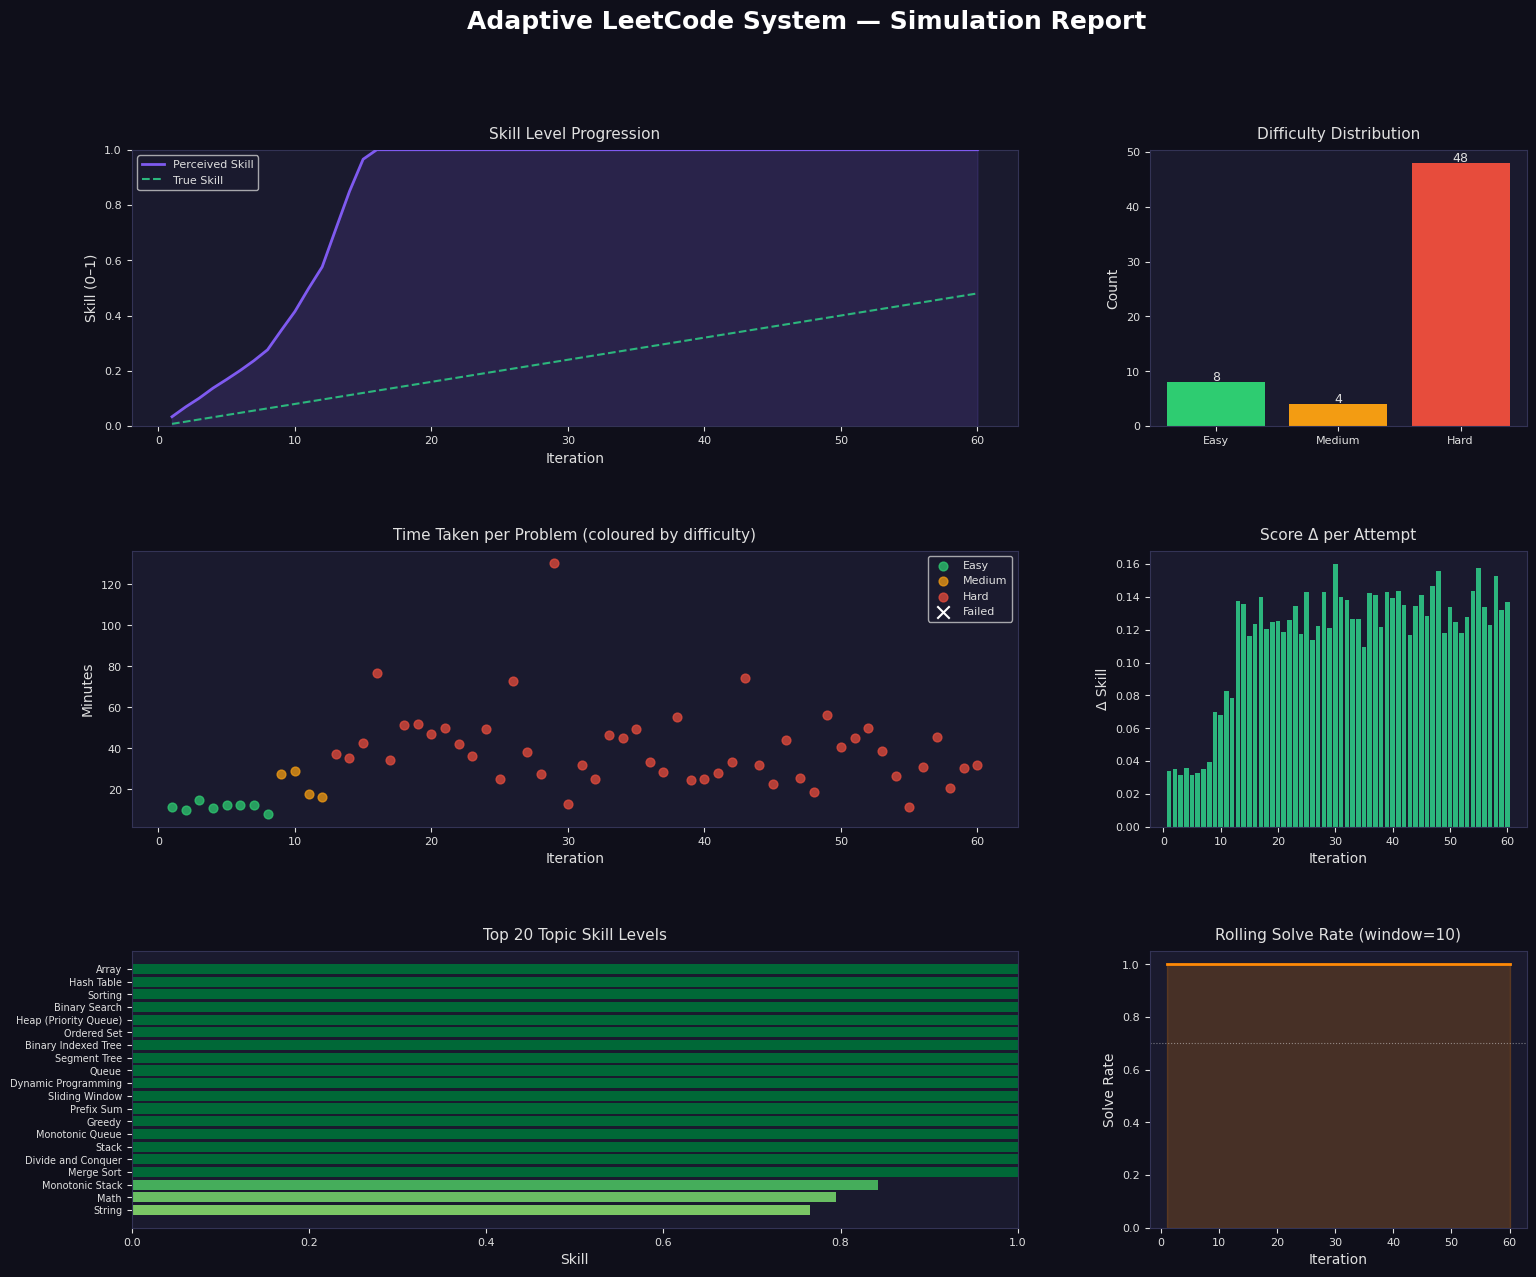

[Plot] Saved → kg_sample.png


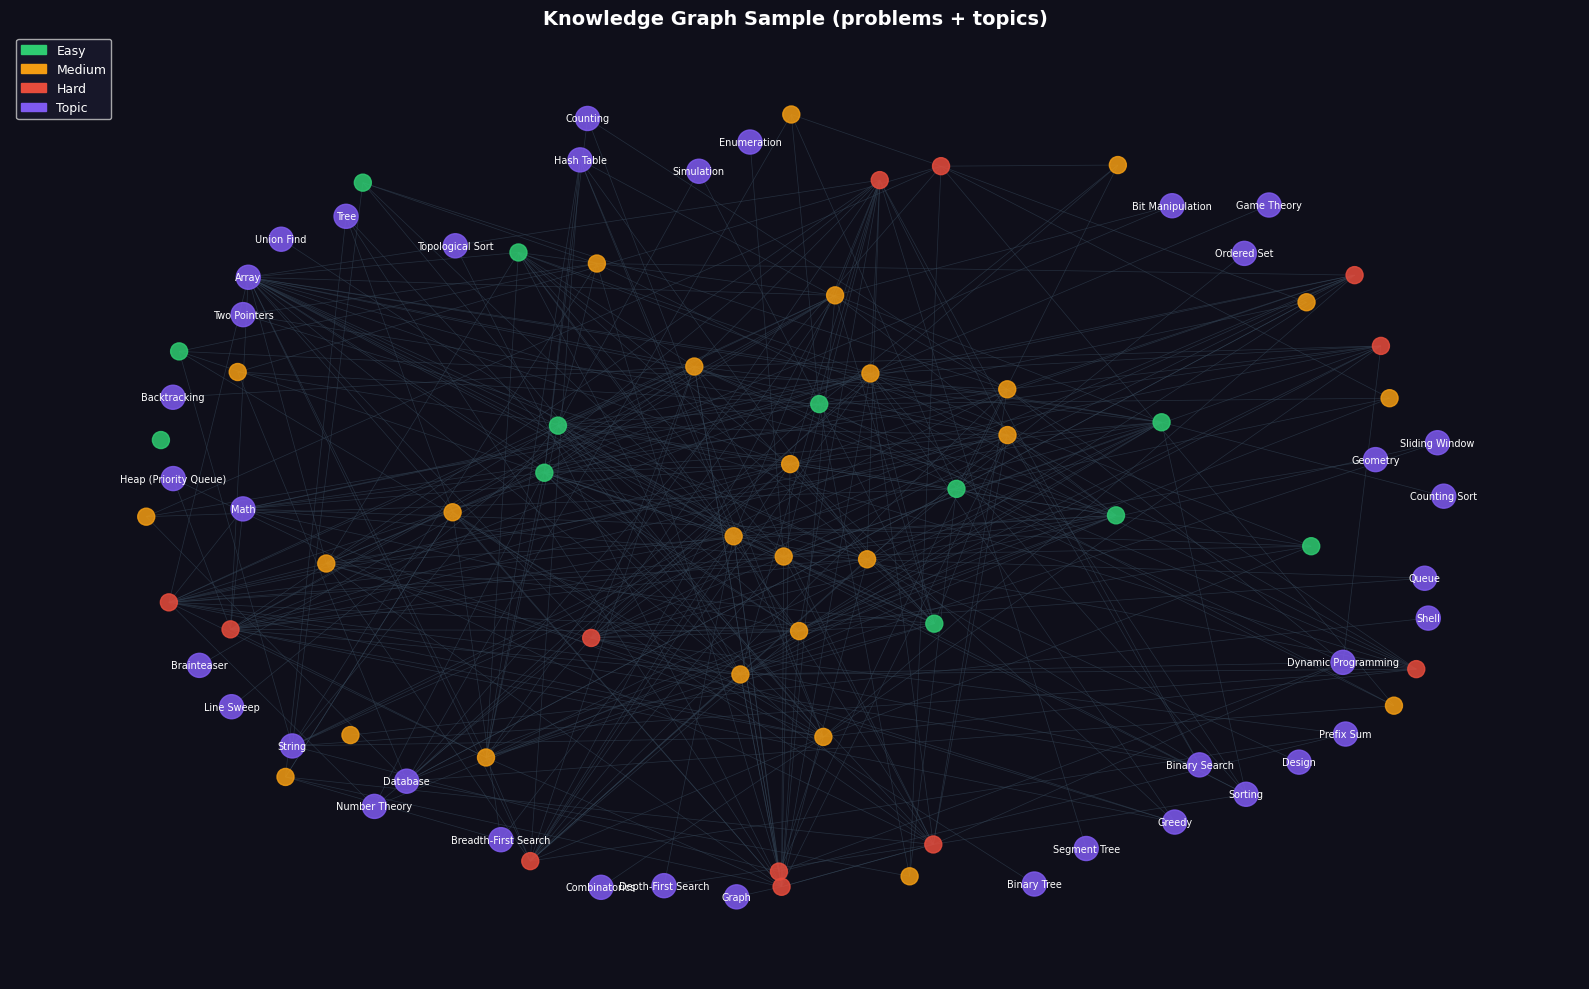

[Log] simulation_log.json saved.


In [5]:

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  8.  ENTRY POINT                                                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

if __name__ == "__main__":
    import sys

    # ── path to your CSV ──────────────────────────────────────────────────────
    CSV_PATH = "/data4/telecom_NER/code_agent/Leetcode Data.csv"

    # ── 1. load ───────────────────────────────────────────────────────────────
    df = load_dataset(CSV_PATH)

    # ── 2. build knowledge graph ──────────────────────────────────────────────
    kg = LeetCodeKnowledgeGraph(df,
                                 model_name="all-MiniLM-L6-v2",
                                 embed_sim_threshold=0.72)

    # ── 3. run 60-iteration simulation ───────────────────────────────────────
    random.seed(42)
    result = run_simulation(df, kg,
                             n_iterations=60,
                             true_skill_start=0.00020)

    # ── 4. plots ──────────────────────────────────────────────────────────────
    plot_simulation(result, save_path="simulation_report.png")
    plot_knowledge_graph_sample(kg, n_problems=50, save_path="kg_sample.png")

    # ── 5. save iteration log to JSON ─────────────────────────────────────────
    with open("simulation_log.json", "w") as f:
        # make serialisable
        safe_logs = [{k: (v if not isinstance(v, (np.integer, np.floating))
                          else float(v))
                      for k, v in log.items()}
                     for log in result["logs"]]
        json.dump(safe_logs, f, indent=2, default=str)
    print("[Log] simulation_log.json saved.")